In [31]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки стилей
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Загрузка датасета Ames Housing / House Prices...")
# Загружаем датасет с официального репозитория OpenML
housing = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = housing.frame

# Приводим названия колонок и типы данных к нужному формату
df['GrLivArea'] = df['GrLivArea'].astype(float)
df['SalePrice'] = df['SalePrice'].astype(float)

print(f"Успешно загружено! Размер таблицы: {df.shape}")
df[['GrLivArea', 'SalePrice']].head()

Загрузка датасета Ames Housing / House Prices...
Успешно загружено! Размер таблицы: (1460, 81)


,GrLivArea,SalePrice
0,1710.0,208500.0
1,1262.0,181500.0
2,1786.0,223500.0
3,1717.0,140000.0
4,2198.0,250000.0


In [32]:
# 1.
q1 = df['GrLivArea'].quantile(0.25)
q3 = df['GrLivArea'].quantile(0.75)

iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_iqr = df[(df['GrLivArea'] < lower_bound) | (df['GrLivArea'] > upper_bound)]
print(len(outliers_iqr))

31


In [33]:
# 2.
z_scores = np.abs(stats.zscore(df['GrLivArea']))
ountliers_z = df[z_scores > 3]
print(len(ountliers_z))

16


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

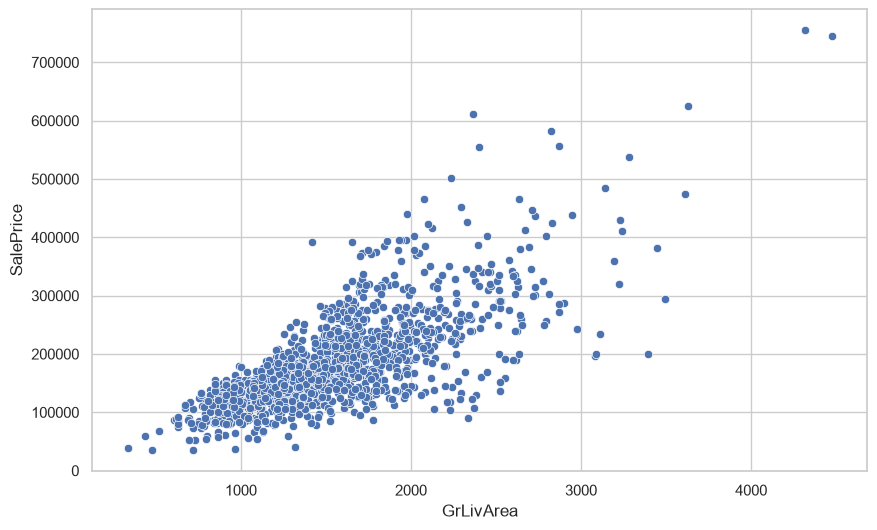

In [37]:
# 3.
df = df[(df['GrLivArea']<4000.0) | (df['SalePrice']>200000.0)]
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')


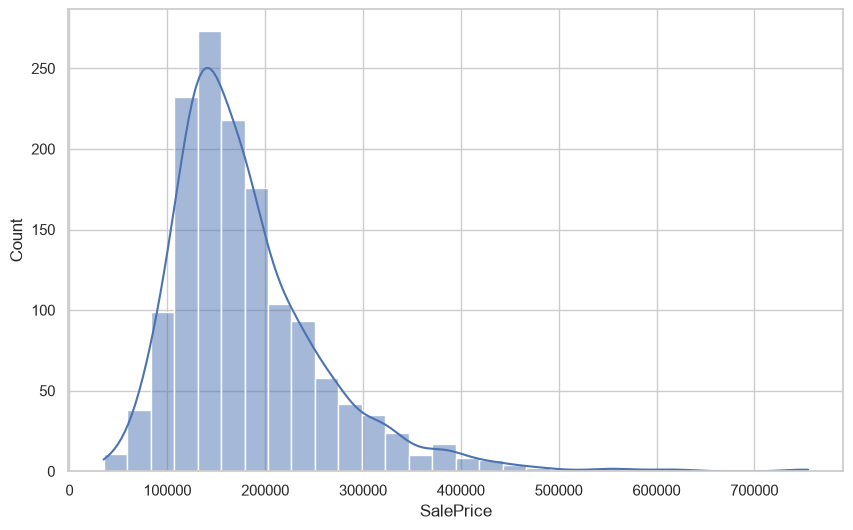

In [ ]:
# 4.
sns.histplot(data=df, x='SalePrice', bins=30, kde=True)
df['log_SalePrice'] = np.log1p(df['SalePrice'])

<Axes: xlabel='log_SalePrice', ylabel='Count'>

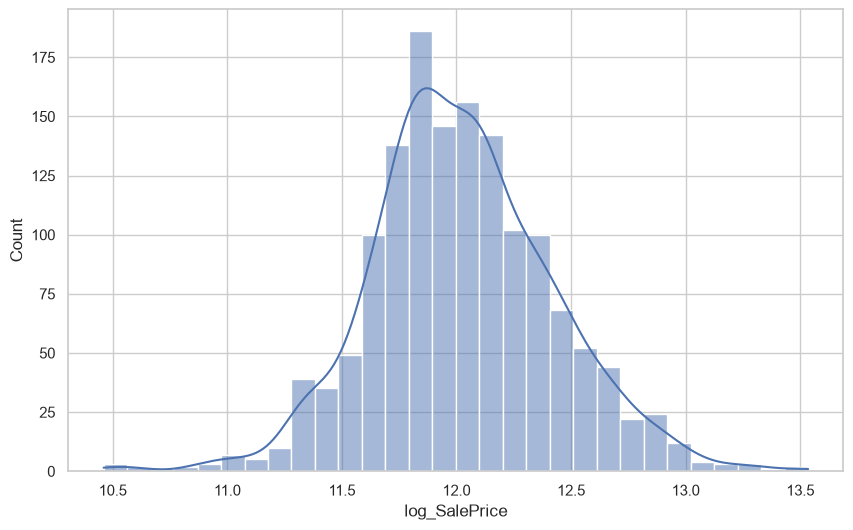

In [36]:
sns.histplot(data=df, x='log_SalePrice', bins=30, kde=True)